[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/05_mechanistic_decomposition.ipynb)

In [1]:
from pathlib import Path
import os, sys, subprocess


def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


if _running_in_colab():
    repo_url = os.environ.get("ASTROMODEL_REPO_URL", "https://github.com/doxav/astromodel_proving.git")
    repo_branch = os.environ.get("ASTROMODEL_REPO_BRANCH", "main")
    project_root = Path("/content") / "astromodel_proving"
    if not project_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", repo_branch, repo_url, str(project_root)], check=True)
    os.chdir(project_root)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    project_root = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
    os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /workspace/astromodel_proving


# Step 05 — Mechanistic decomposition of accepted cell ensembles

This notebook validates the Step 05 reviewer-response pipeline. It loads accepted Step 04 cell-level ensembles, simulates hidden outputs with the canonical local astrocyte model, decomposes accepted fits into Kir/gap/leak mechanism summaries, clusters in effective/mechanism space, and records conservative claim scope.

The implementation reuses the local model and ATF conventions developed from `analysis/astro_atf_analysis_improved_sectioned.ipynb`. Step 05 can identify candidate mechanism regimes or compensation manifolds, but predictive and perturbation support remains pending until Step 06.

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from src.step05_mechanistic_decomposition import Step05Config, run_step05_mechanistic_decomposition

config = Step05Config(max_candidates=4, time_points=120, bootstrap_iterations=8, random_seed=13, write_outputs=True)
result = run_step05_mechanistic_decomposition(project_root, config)
out_dir = project_root / "outputs" / "mechanisms"
print(json.dumps(result["analysis_summary"], indent=2))

{
  "step_name": "Step 05 \u2014 Mechanistic decomposition of accepted cell ensembles",
  "input_source": "outputs/cell_fits/accepted_cell_ensembles.csv",
  "config": {
    "max_candidates": 4,
    "time_points": 120,
    "t_final_ms": 50000.0,
    "n_clusters": 3,
    "bootstrap_iterations": 8,
    "random_seed": 13,
    "max_representatives": 3,
    "interpolation_points": 5,
    "small_stratum_min_cells": 3,
    "write_outputs": true
  },
  "n_input_candidates": 4,
  "n_candidate_sweep_rows": 24,
  "n_successful_sweep_simulations": 24,
  "n_mechanism_clusters": 3,
  "headline_claim_scope": "candidate_mechanism_regimes_pending_validation",
  "elapsed_seconds": 2.2951793430002
}


## 1. Accepted ensemble inventory

In [3]:
clusters = result["mechanism_clusters"]
flux = result["accepted_fit_mechanisms"]
inventory = clusters.groupby(["region", "condition"], as_index=False).agg(
    n_cells=("file_id", "nunique"),
    n_candidates=("candidate_id", "nunique"),
    n_clusters=("mechanism_cluster", "nunique"),
)
inventory

,region,condition,n_cells,n_candidates,n_clusters
0,DH,CONTROL,1,3,2
1,DH,MFA,1,1,1


## 2. Candidate-sweep flux decomposition table

In [4]:
flux_cols = [
    "file_id", "region", "condition", "candidate_id", "sweep", "current_na", "simulation_status",
    "I_Kir_integral", "I_kgap_integral", "I_leak_integral", "gap_to_kir_integral_ratio",
    "gap_fraction", "kir_fraction", "leak_fraction", "K_o_peak", "K_o_recovery_error", "proxy_validity_class",
]
flux[flux_cols].head(12)

,file_id,region,condition,candidate_id,sweep,current_na,simulation_status,I_Kir_integral,I_kgap_integral,I_leak_integral,gap_to_kir_integral_ratio,gap_fraction,kir_fraction,leak_fraction,K_o_peak,K_o_recovery_error,proxy_validity_class
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,1,50,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
1,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,2,75,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
2,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,3,100,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
3,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,4,125,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
4,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,5,150,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
5,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,6,175,ok,15152.605492,15161.786195,9.267818,1.000606,0.499999,0.499696,0.000306,5.968027,0.017102,failed
6,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,1,50,ok,14363.559625,14357.678982,9.040199,0.999591,0.499740,0.499945,0.000315,6.089442,0.016845,failed
7,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,2,75,ok,14363.559625,14357.678982,9.040199,0.999591,0.499740,0.499945,0.000315,6.089442,0.016845,failed
8,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,3,100,ok,14363.559625,14357.678982,9.040199,0.999591,0.499740,0.499945,0.000315,6.089442,0.016845,failed
9,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,4,125,ok,14363.559625,14357.678982,9.040199,0.999591,0.499740,0.499945,0.000315,6.089442,0.016845,failed


## 3. Mechanism-space clustering

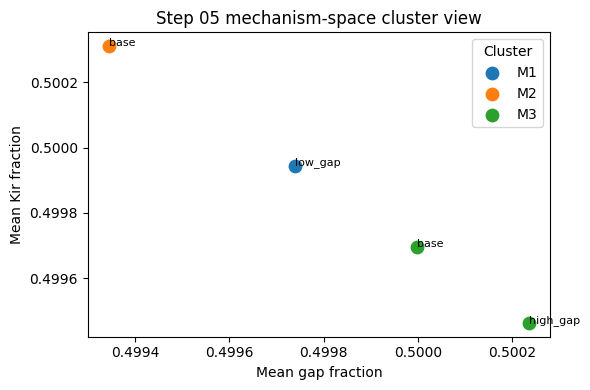

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, sub in clusters.groupby("mechanism_cluster"):
    ax.scatter(sub["gap_fraction_mean"], sub["kir_fraction_mean"], s=80, label=label)
for _, row in clusters.iterrows():
    ax.annotate(str(row["candidate_id"]).split("__")[-1], (row["gap_fraction_mean"], row["kir_fraction_mean"]), fontsize=8)
ax.set_xlabel("Mean gap fraction")
ax.set_ylabel("Mean Kir fraction")
ax.set_title("Step 05 mechanism-space cluster view")
ax.legend(title="Cluster")
fig.tight_layout()
plt.show()

## 4. Flux decomposition for representative candidates

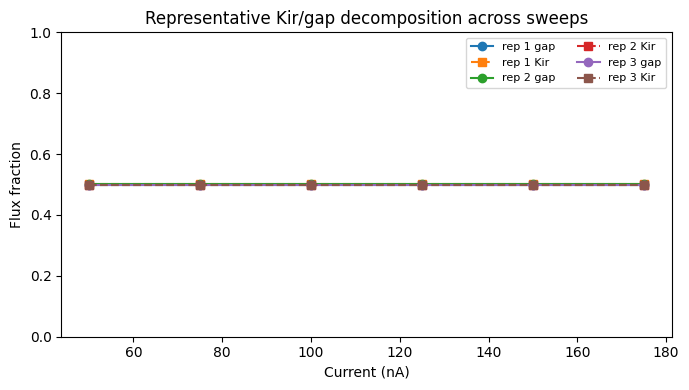

,representative_rank,file_id,condition,mechanism_cluster,dominant_mechanism,claim_scope
0,1,DH_1_MFA,MFA,M2,Mixed,candidate_mechanism_regime_pending_step06_vali...
1,2,1_DH_1,CONTROL,M3,Mixed,candidate_mechanism_regime_pending_step06_vali...
2,3,1_DH_1,CONTROL,M1,Mixed,candidate_mechanism_regime_pending_step06_vali...


In [6]:
reps = result["representatives"]
rep_flux = flux.merge(reps[["file_id", "candidate_id", "representative_rank"]], on=["file_id", "candidate_id"], how="inner")
fig, ax = plt.subplots(figsize=(7, 4))
for (rank, candidate_id), sub in rep_flux.groupby(["representative_rank", "candidate_id"]):
    sub = sub.sort_values("current_na")
    ax.plot(sub["current_na"], sub["gap_fraction"], marker="o", label=f"rep {rank} gap")
    ax.plot(sub["current_na"], sub["kir_fraction"], marker="s", linestyle="--", label=f"rep {rank} Kir")
ax.set_xlabel("Current (nA)")
ax.set_ylabel("Flux fraction")
ax.set_ylim(0, 1)
ax.set_title("Representative Kir/gap decomposition across sweeps")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
reps[["representative_rank", "file_id", "condition", "mechanism_cluster", "dominant_mechanism", "claim_scope"]]

## 5. Compensation-vs-separated-mode interpolation diagnostics

In [7]:
geometry = result["geometry_classification"]
geometry

,cluster_a,cluster_b,n_interpolation_points,interpolation_status,geometry_classification,validation_status
0,M1,M2,5,effective_space_screened,separated_modes_pending_validation,pending_step06
1,M1,M3,5,effective_space_screened,compensation_manifold,pending_step06
2,M2,M3,5,effective_space_screened,separated_modes_pending_validation,pending_step06


## 6. Bootstrap stability table

In [8]:
stability = result["bootstrap_cluster_stability"]
stability.describe(include="all")

,bootstrap_iteration,n_cells,n_candidates,coassignment_stability,stability_status
count,8.00000,8.000000,8.000000,8.0,8
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,stable
freq,NaN,NaN,NaN,NaN,8
mean,4.50000,1.375000,3.250000,1.0,NaN
std,2.44949,0.517549,1.488048,0.0,NaN
min,1.00000,1.000000,2.000000,1.0,NaN
25%,2.75000,1.000000,2.000000,1.0,NaN
50%,4.50000,1.000000,3.000000,1.0,NaN
75%,6.25000,2.000000,4.000000,1.0,NaN


## 7. DH/VH and condition occupancy table

In [9]:
enrichment = result["region_mechanism_enrichment"]
enrichment.sort_values(["region", "condition", "mechanism_cluster"])

,region,condition,mechanism_cluster,n_candidates,n_cells,total_candidates,total_cells,candidate_fraction,small_stratum_flag,interpretation_scope
0,DH,CONTROL,M1,1,1,3,2,0.333333,True,population_level_cell_association_not_phenotyp...
1,DH,CONTROL,M3,2,1,3,2,0.666667,True,population_level_cell_association_not_phenotyp...
2,DH,MFA,M2,1,1,1,1,1.000000,True,population_level_cell_association_not_phenotyp...


## 8. Explicit claim-scope table

In [10]:
claims = result["claim_scope_table"]
claims

,claim_topic,allowed_pre_step06_claim,forbidden_pre_step06_claim,required_next_step,n_clusters
0,mechanism_diversity,candidate_mechanism_regimes_pending_validation,candidate_degenerate_regimes,Step 06 predictive and perturbation validation,3
1,region_enrichment,population_level_cell_association_not_phenotyp...,paired_pharmacology_or_animal_level_phenotype,larger stratified validation and Step 06 robus...,3


In [11]:
assert (flux["simulation_status"] == "ok").any()
assert {"region", "condition", "mechanism_cluster"}.issubset(clusters.columns)
assert claims["forbidden_pre_step06_claim"].str.contains("candidate_degenerate_regimes").any()
print(f"Step 05 notebook validated and outputs saved under {out_dir}")

Step 05 notebook validated and outputs saved under /workspace/astromodel_proving/outputs/mechanisms
